In [18]:
from engioptiqa import AnnealingSolverAmplify, TrussStructure, TrussStructureOptimization

In [19]:
token_dict = {
    'fixstars': '/usr2/key/Projects/QuantumComputing/QuantumAnnealing/token_Fixstars.txt',
    'toshiba': '/usr2/key/Projects/QuantumComputing/QuantumAnnealing/token_Toshiba.txt',
}
proxy='http://proxy.ilsb.tuwien.ac.at:3128'
annealing_solver_gpu = AnnealingSolverAmplify(client_type='fixstars', token_file=token_dict['fixstars'], proxy=proxy)
annealing_solver_gpu.setup_solver()

annealing_solver_sqbm = AnnealingSolverAmplify(client_type='toshiba', token_file=token_dict['toshiba'], proxy=proxy)
annealing_solver_sqbm.setup_solver()
from datetime import timedelta
annealing_solver_sqbm.client.parameters.timeout = timedelta(milliseconds=1e4)

Setting default timeout (ms): 800
Created solver
Choosing default solver: Pubo
Setting default timeout (ms): 1000
Created solver


In [20]:
ts_opt = TrussStructureOptimization()

In [21]:
def create_truss_structure_6_elements(ts, visualize=True):

    ts.add_node(0, (0,0))  # Node 0 at (0,0)
    ts.add_node(1, (1,0))  # Node 1 at (1,0)
    ts.add_node(2, (1,1))  # Node 2 at (1,1)
    ts.add_node(3, (0,1))  # Node 3 at (0,1)

    ts.add_member(0, 1, A=0.5, E=2e11)  # Member from Node 0 to Node 1
    ts.add_member(1, 2, A=0.5, E=2e11)  # Member from Node 1 to Node 2
    ts.add_member(2, 3, A=0.5, E=2e11)  # Member from Node 2 to Node 3
    ts.add_member(3, 0, A=0.5, E=2e11)  # Member from Node 3 to Node 0
    ts.add_member(0, 2, A=0.5, E=2e11)  # Diagonal Member from Node 0 to Node 2
    ts.add_member(1, 3, A=0.5, E=2e11)  # Diagonal Member from Node 1 to Node 3

    ts.add_load(1, (0, -100e3))  # Vertical load of -100 N at Node 1

    ts.add_support(0, True, True)  # Fixed support at Node 0
    ts.add_support(3, True, True)  # Fixed support at Node 3

    if visualize:
        ts.visualize()

In [22]:
def create_truss_structure_11_elements(ts, visualize=True):
    ts.add_node(0, (0,0))  # Node 0 at (0,0)
    ts.add_node(1, (1,0))  # Node 1 at (1,0)
    ts.add_node(2, (1,1))  # Node 2 at (1,1)
    ts.add_node(3, (0,1))  # Node 3 at (0,1)

    ts.add_node(4, (0,-1))
    ts.add_node(5, (1,-1))

    ts.add_member(0, 1, A=0.5, E=2e11)  # Member from Node 0 to Node 1
    ts.add_member(1, 2, A=0.5, E=2e11)  # Member from Node 1 to Node 2
    ts.add_member(2, 3, A=0.5, E=2e11)  # Member from Node 2 to Node 3
    ts.add_member(3, 0, A=0.5, E=2e11)  # Member from Node 3 to Node 0
    ts.add_member(0, 2, A=0.5, E=2e11)  # Diagonal Member from Node 0 to Node 2
    ts.add_member(1, 3, A=0.5, E=2e11)  # Diagonal Member from Node 1 to Node 3

    ts.add_member(0, 4, A=0.5, E=2e11)
    ts.add_member(4, 5, A=0.5, E=2e11)
    ts.add_member(5, 1, A=0.5, E=2e11)
    ts.add_member(4, 1, A=0.5, E=2e11)
    ts.add_member(0, 5, A=0.5, E=2e11)

    ts.add_load(1, (0, -100e3))  # Vertical load of -100 N at Node 1

    ts.add_support(0, True, True)  # Fixed support at Node 0
    ts.add_support(3, True, True)  # Fixed support at Node 3

    ts.add_support(4, True, True)

    if visualize:
        ts.visualize()

In [23]:
def create_truss_structure_29_elements(ts, A=0.5, E=2e11, visualize=True):
    # Add nodes
    n_x = 4; n_y =3
    x_min, x_max, y_min, y_max = 0, 0.75, 0, 0.5
    for i in range(n_x):
        for j in range(n_y):
            node_id = i * n_y + j
            x = x_min + i * (x_max - x_min) / (n_x - 1)
            y = y_min + j * (y_max - y_min) / (n_y - 1)
            ts.add_node(node_id, (x, y))

    # Add members
    for i in range(n_x):
        for j in range(n_y):
            node_id = i * n_y + j
            if i < n_x - 1:
                ts.add_member(node_id, (i + 1) * n_y + j, A=A, E=E)  # Horizontal member
            if j < n_y - 1:
                ts.add_member(node_id, i * n_y + (j + 1), A=A, E=E)  # Vertical member
            if i < n_x - 1 and j < n_y - 1:
                ts.add_member(node_id, (i + 1) * n_y + (j + 1), A=A, E=E)  # Diagonal member
            if i < n_x - 1 and j > 0:
                ts.add_member(node_id, (i + 1) * n_y + (j - 1), A=A, E=E)  # Diagonal member

    # Add supports
    ts.add_support(0, True, True)  # Fixed support at Node 0
    ts.add_support(1, True, True)  # Fixed support at Node 1
    ts.add_support(2, True, True)  # Fixed support at Node 2

    # Add loads
    ts.add_load(9, (0, -10e3))  # Vertical load

    if visualize:
        ts.visualize()

Max Area: 0.5


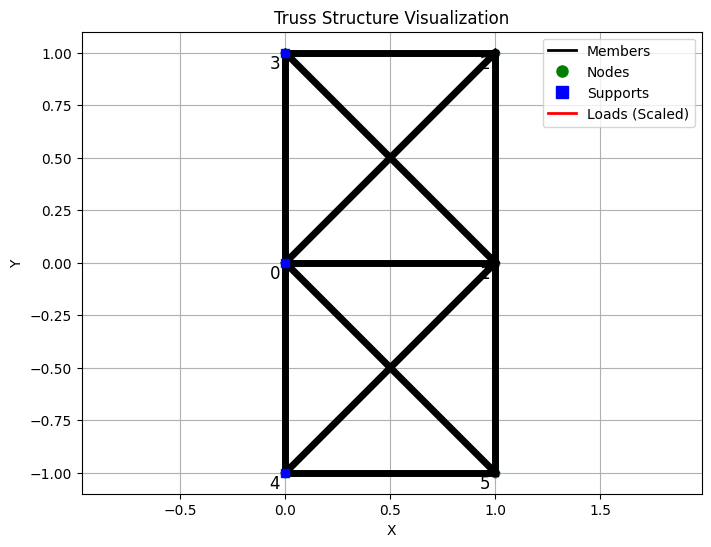

In [24]:
# create_truss_structure_6_elements(ts_opt)
create_truss_structure_11_elements(ts_opt)
# create_truss_structure_29_elements(ts_opt)

In [25]:
len(ts_opt.members)

11

In [26]:
member_forces, compliance = ts_opt.compute_member_forces()
print("Member Forces:")
for i_member, force in member_forces.items():
    print(f"\tF_{i_member} = {force} ")

Compliance: 0.08918058124456127
Member Forces:
	F_0 = 0.0 
	F_1 = 18469.90312590647 
	F_2 = 18469.903125906476 
	F_3 = 0.0 
	F_4 = -26120.387496374162 
	F_5 = 44590.29062228063 
	F_6 = 0.0 
	F_7 = -18469.903125906476 
	F_8 = -18469.903125906458 
	F_9 = -44590.29062228063 
	F_10 = 26120.38749637417 


In [27]:
member_areas = [member.A for member in ts_opt.members]
V_0 = ts_opt.total_volume(member_areas)
print(f"Initial total volume: {V_0}")

Initial total volume: 6.328427124746191


In [28]:
ts_opt.generate_discretization(n_qubits_per_member=16,
                               binary_representation='range',
                               lower_lim=-4e5, upper_lim=4e5)

TrussStructureOptimization: Generating member area inverse polynomials.


In [29]:
ts_opt.generate_objective(penalty_weight_joints=1e-1, target_volume=V_0, penalty_weight_volume=1e3)

Node 0
Node 1
	Residual force in x-direction: - 6.10360875867857 q_0 q'''''''''''_0 - 12.2072175173571 q_1 q'''''''''''_0 - 24.4144350347143 q_2 q'''''''''''_0 - 48.8288700694285 q_3 q'''''''''''_0 - 97.6577401388571 q_4 q'''''''''''_0 - 195.315480277714 q_5 q'''''''''''_0 - 390.630960555428 q_6 q'''''''''''_0 - 781.261921110857 q_7 q'''''''''''_0 - 1562.52384222171 q_8 q'''''''''''_0 - 3125.04768444343 q_9 q'''''''''''_0 - 6250.09536888685 q_{10} q'''''''''''_0 - 12500.1907377737 q_{11} q'''''''''''_0 - 25000.3814755474 q_{12} q'''''''''''_0 - 50000.7629510948 q_{13} q'''''''''''_0 - 100001.52590219 q_{14} q'''''''''''_0 - 200003.051804379 q_{15} q'''''''''''_0 - 4.31590314297122 q'''''_0 q''''''''''''''''_0 - 8.63180628594244 q'''''_1 q''''''''''''''''_0 - 17.2636125718849 q'''''_2 q''''''''''''''''_0 - 34.5272251437698 q'''''_3 q''''''''''''''''_0 - 69.0544502875395 q'''''_4 q''''''''''''''''_0 - 138.108900575079 q'''''_5 q''''''''''''''''_0 - 276.217801150158 q'''''_6 q''''''''''''

In [30]:
# annealing_solver_gpu.solve_problem(ts_opt)

annealing_solver_sqbm.solve_problem(ts_opt)

Number of solutions: 1


In [31]:
best_solution, solutions = ts_opt.analyze_results()

Node 0
Node 1
	Residual force in x-direction: 69.05445028754912
	Residual force in y-direction:  21.055338358062727
Node 2
	Residual force in x-direction: 0.0
	Residual force in y-direction:  0.0
Node 3
Node 4
Node 5
	Residual force in x-direction: 0.0
	Residual force in y-direction:  0.0
Best solution (minimum objective):
Objective: 1935.4687406536223
Complementary Energy: 0.07074049171702612
Volume: 1.4142135623730951
Joint Residuals (squared): 5211.8443778881
Member Forces: [0.0, -0.0, 0.0, -0.0, 0.0, 70676.73762111849, -0.0, 0.0, -0.0, -70774.39536125735, 0.0]
Member Stresses: [176839.8565651942, -47406.72922865645, 20257.87747005414, -216256.96192874038, 70759.13633936062, 141353.47524223698, -265757.22896162356, 100825.51308461127, -262681.01014724956, -141548.7907225147, 10345.616845960147]
Member Areas: [0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 0.0, 0.0, 0.0, 0.5, 0.0]


Max Area: 0.5


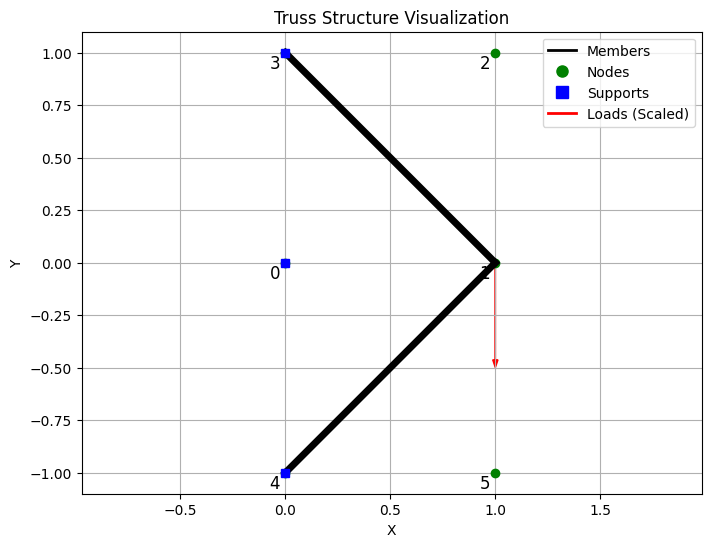

In [32]:
ts_opt.set_member_areas(best_solution['member_areas'])
ts_opt.visualize()

Max Area: 0.5


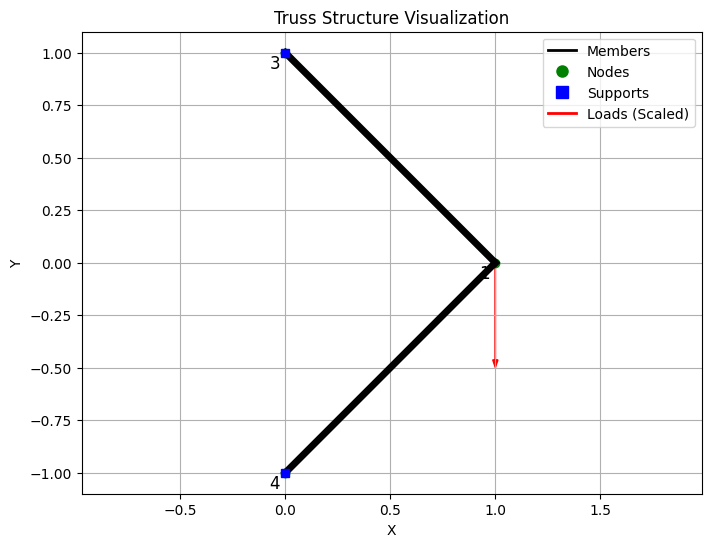

In [33]:
ts_ref = TrussStructure()

nodes_ref = {}
for i_member, member_area in enumerate(best_solution['member_areas']):
    if member_area > 0:
        member_nodes = (ts_opt.members[i_member].node_id_0, ts_opt.members[i_member].node_id_1)
        if member_nodes[0] not in nodes_ref:
            ts_ref.add_node(member_nodes[0], ts_opt.members[i_member].get_coords(0))
        if member_nodes[1] not in nodes_ref:
            ts_ref.add_node(member_nodes[1], ts_opt.members[i_member].get_coords(1))
        ts_ref.add_member(member_nodes[0], member_nodes[1], A=member_area , E=2e11, member_id=i_member)

ts_ref.add_load(1, (0, -100e3))  # Vertical load of -100 N at Node 1
# ts_ref.add_support(0, True, True)  # Fixed support at Node 0
ts_ref.add_support(3, True, True)  # Fixed support at Node 3
ts_ref.add_support(4, True, True)  # Fixed support at Node 3
ts_ref.visualize()

In [34]:
member_forces, compliance = ts_ref.compute_member_forces()
rel_error_compliance = abs((compliance-2*best_solution["complementary_energy"]))/abs(compliance)
print('Compliance:')
print('===========')
print(f'  Reference: {compliance:.8e}')
print(f'  Solution {2*best_solution["complementary_energy"]:.8e}')
print(f'  Rel. Diff: {rel_error_compliance:.2e}')
print('Force:')
print('======')
for i_member_ref, member in enumerate(ts_ref.members):
    i_member = member.member_id
    rel_error_force = abs((member_forces[i_member_ref]-best_solution["member_forces"][i_member]))/abs(member_forces[i_member_ref])
    print(f'  Member {i_member}:')
    print(f'    Reference: {member_forces[i_member_ref]:.8e}')
    print(f'    Solution {best_solution["member_forces"][i_member]:.8e}')
    print(f'    Rel. Diff: {rel_error_force:.2e}')

Compliance: 0.14142135623730953
Compliance:
  Reference: 1.41421356e-01
  Solution 1.41480983e-01
  Rel. Diff: 4.22e-04
Force:
  Member 5:
    Reference: 7.07106781e+04
    Solution 7.06767376e+04
    Rel. Diff: 4.80e-04
  Member 9:
    Reference: -7.07106781e+04
    Solution -7.07743954e+04
    Rel. Diff: 9.01e-04
